Saving WineQT.csv to WineQT.csv
WINE QUALITY DATASET OVERVIEW
Dataset shape: (1143, 13)
Number of samples: 1143
Number of features: 13

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4          

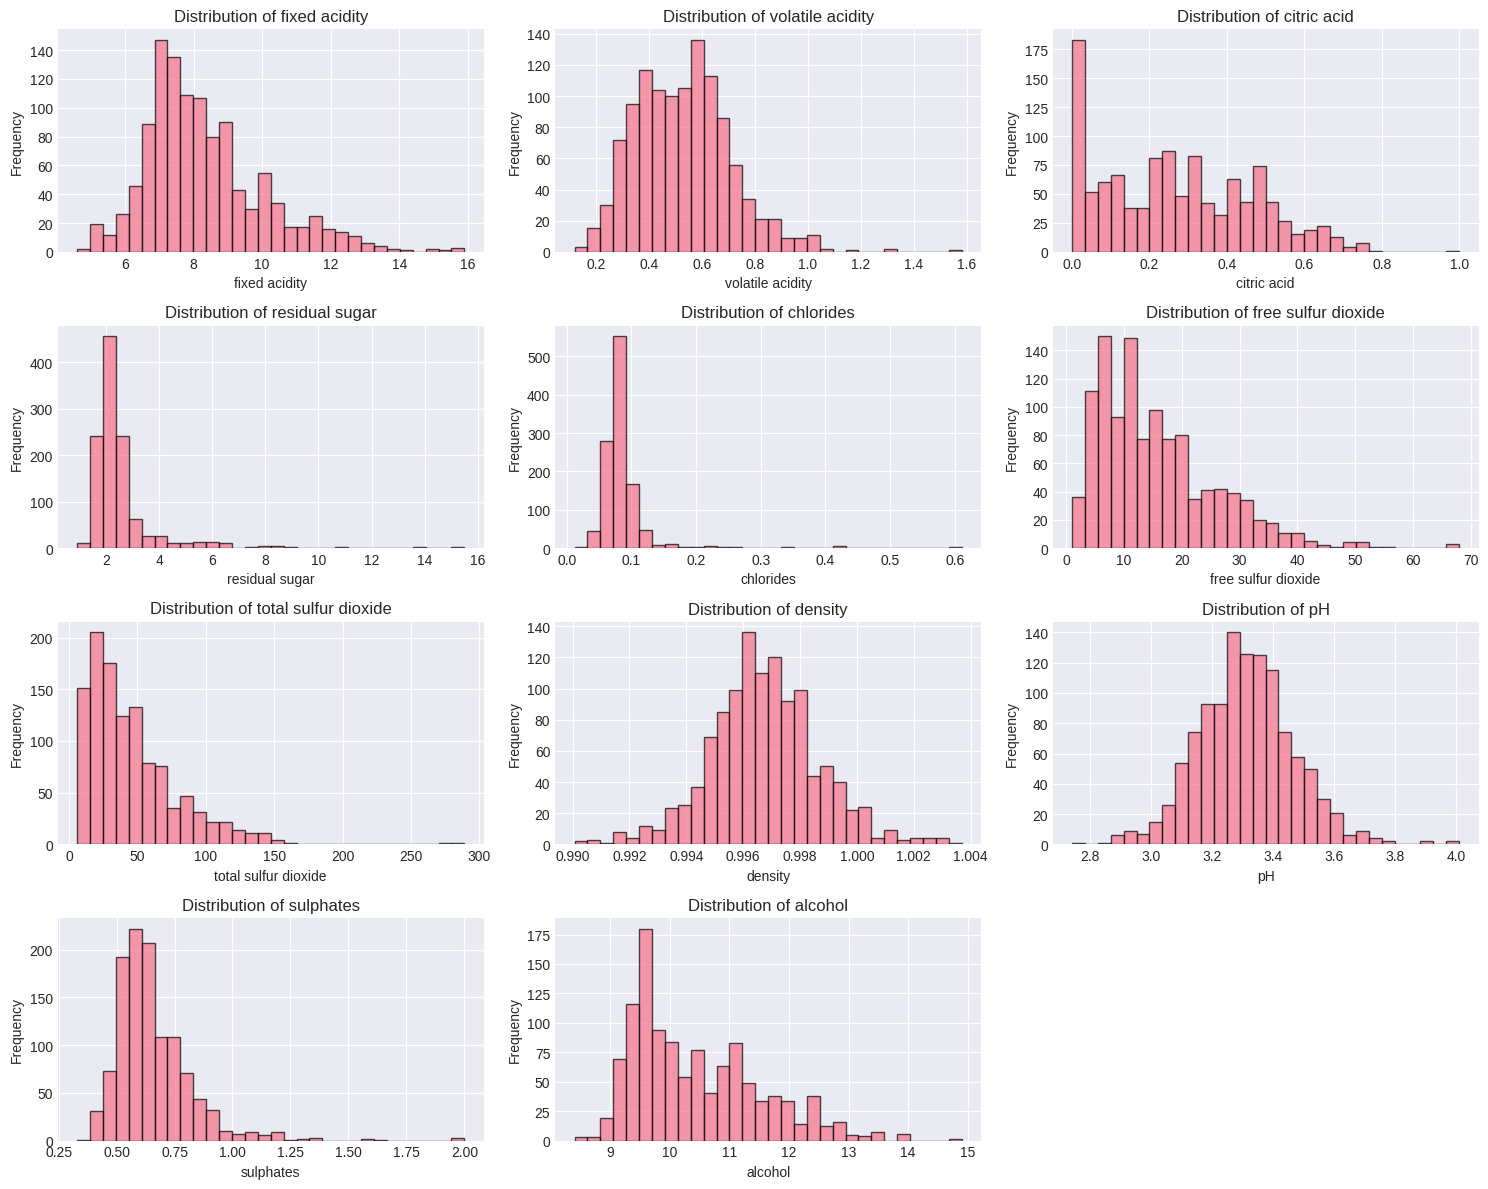

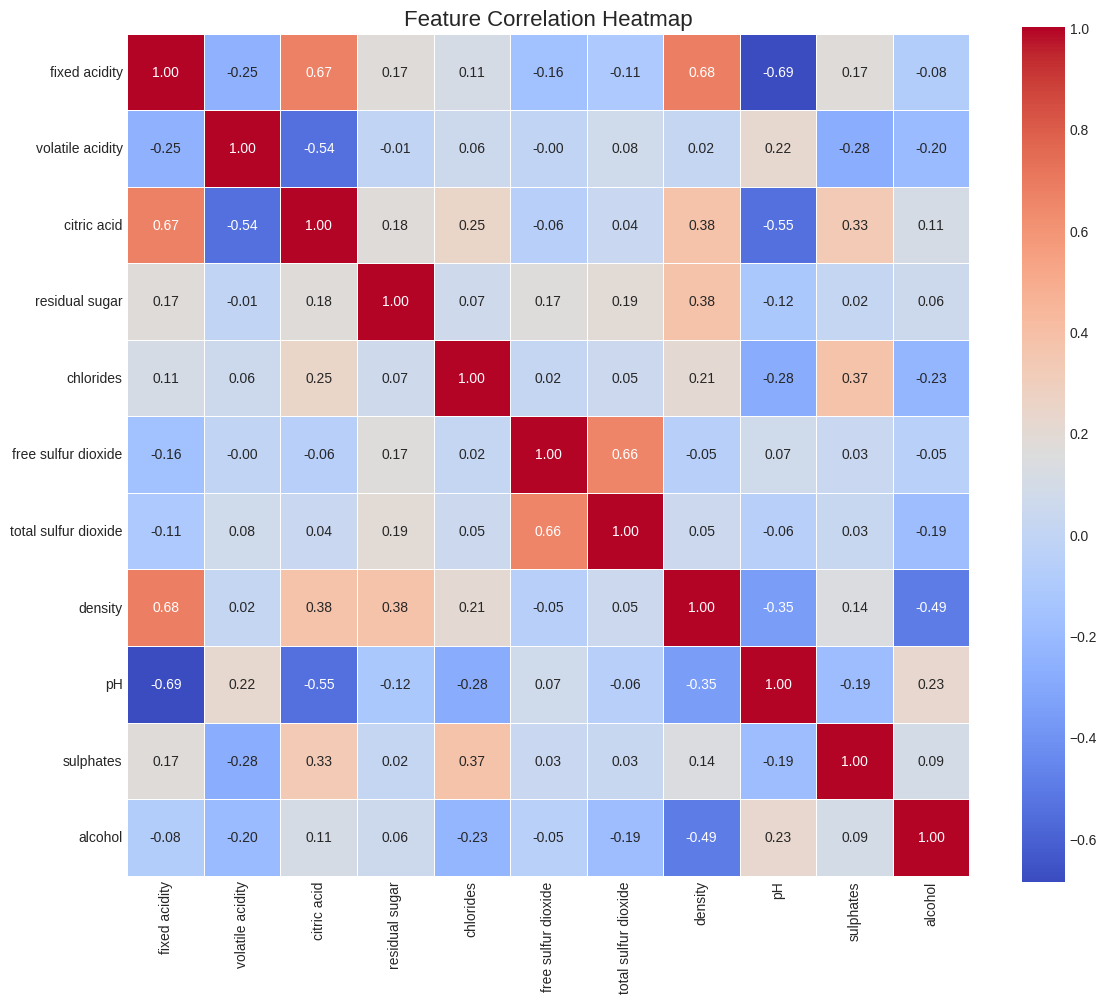

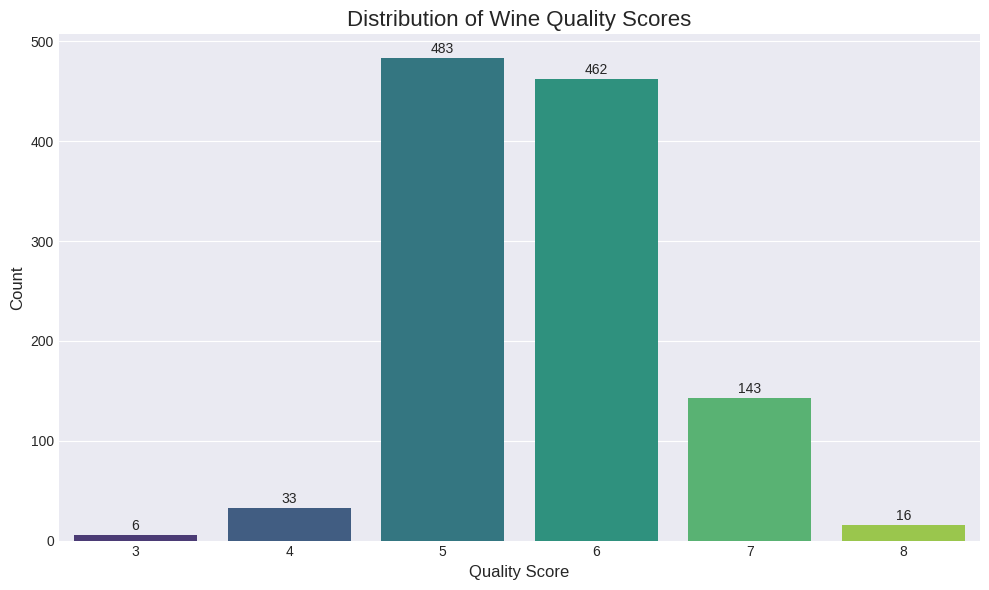

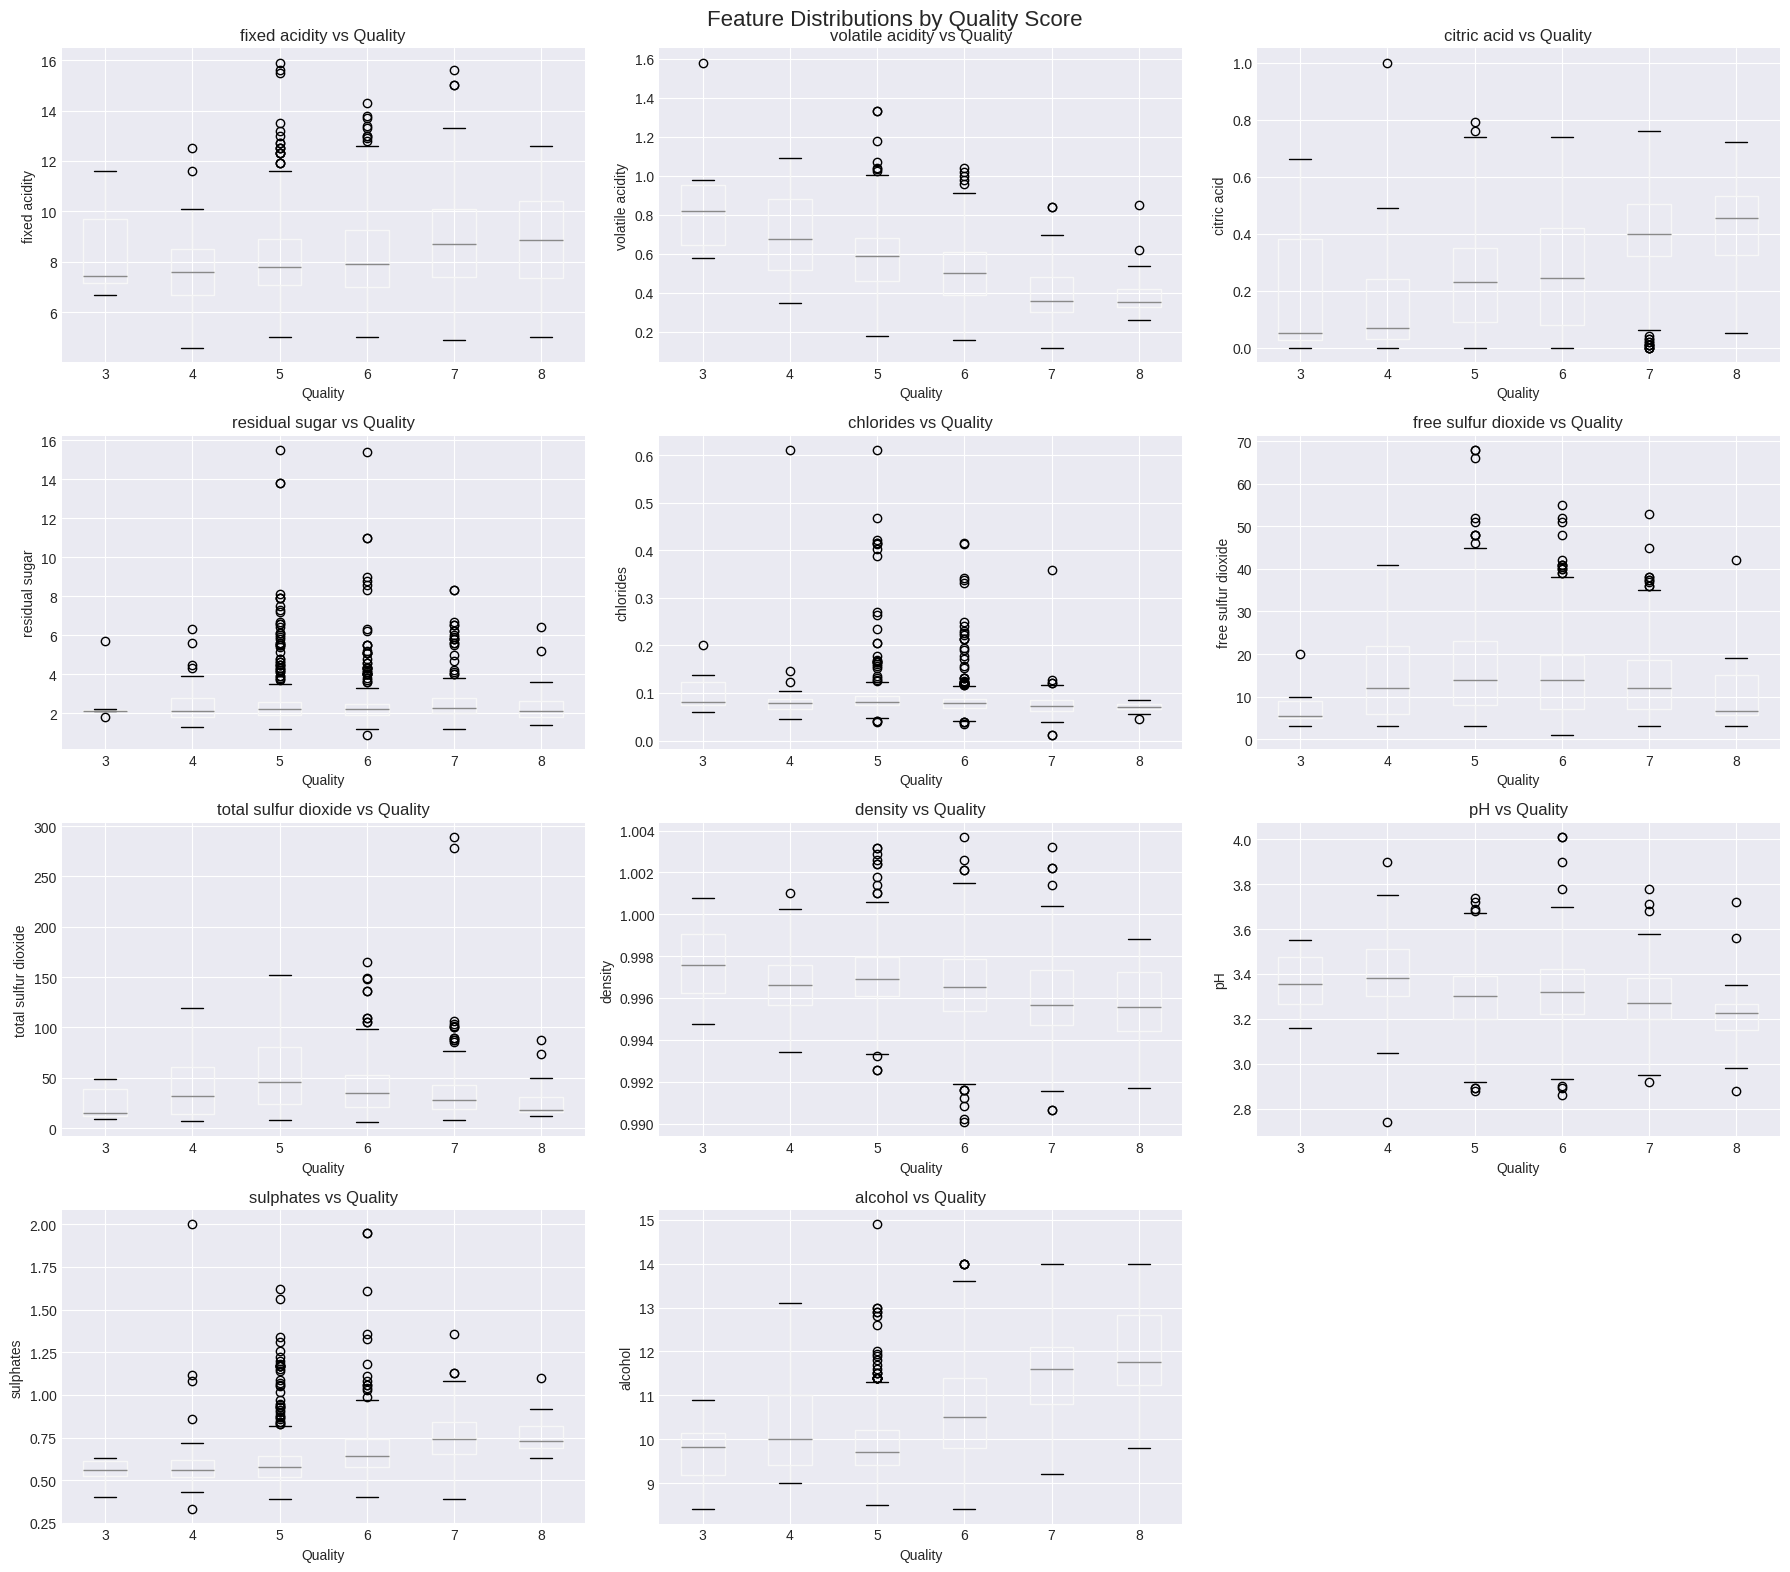


DATA PREPROCESSING
Training set size: 914 samples
Test set size: 229 samples
Features standardized using StandardScaler

MODEL BUILDING AND EVALUATION

--- Random Forest Classifier ---
Accuracy: 0.6769

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.71      0.82      0.76        97
           6       0.64      0.68      0.66        92
           7       0.71      0.41      0.52        29
           8       0.00      0.00      0.00         3

    accuracy                           0.68       229
   macro avg       0.34      0.32      0.32       229
weighted avg       0.64      0.68      0.65       229


Top 5 Most Important Features:
                 feature  importance
10               alcohol    0.175832
9              sulphates    0.127561
1       volatile acidity    0.106288
6   total sulfur dioxide    0.093438
7            

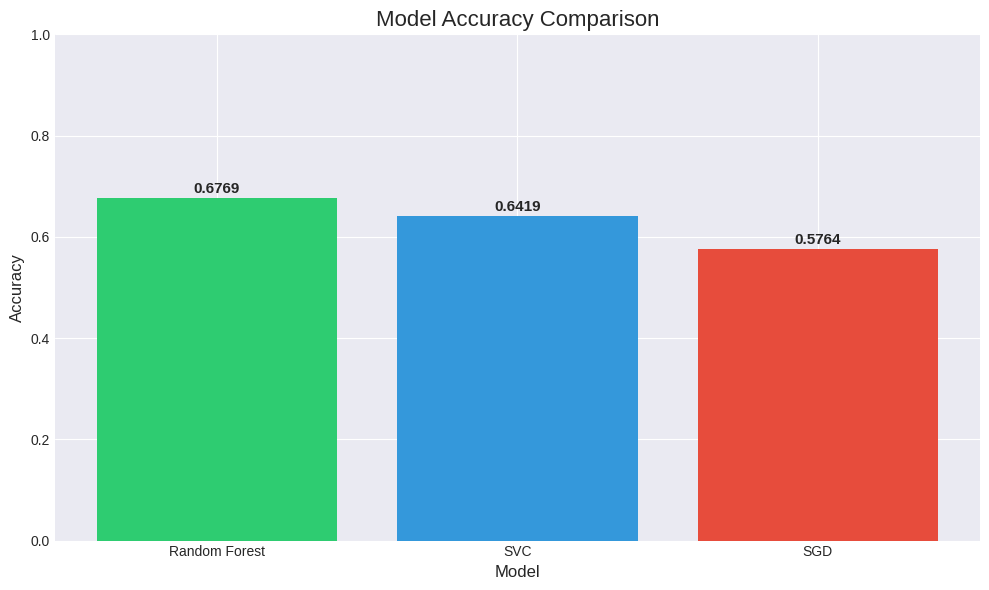


CONFUSION MATRICES


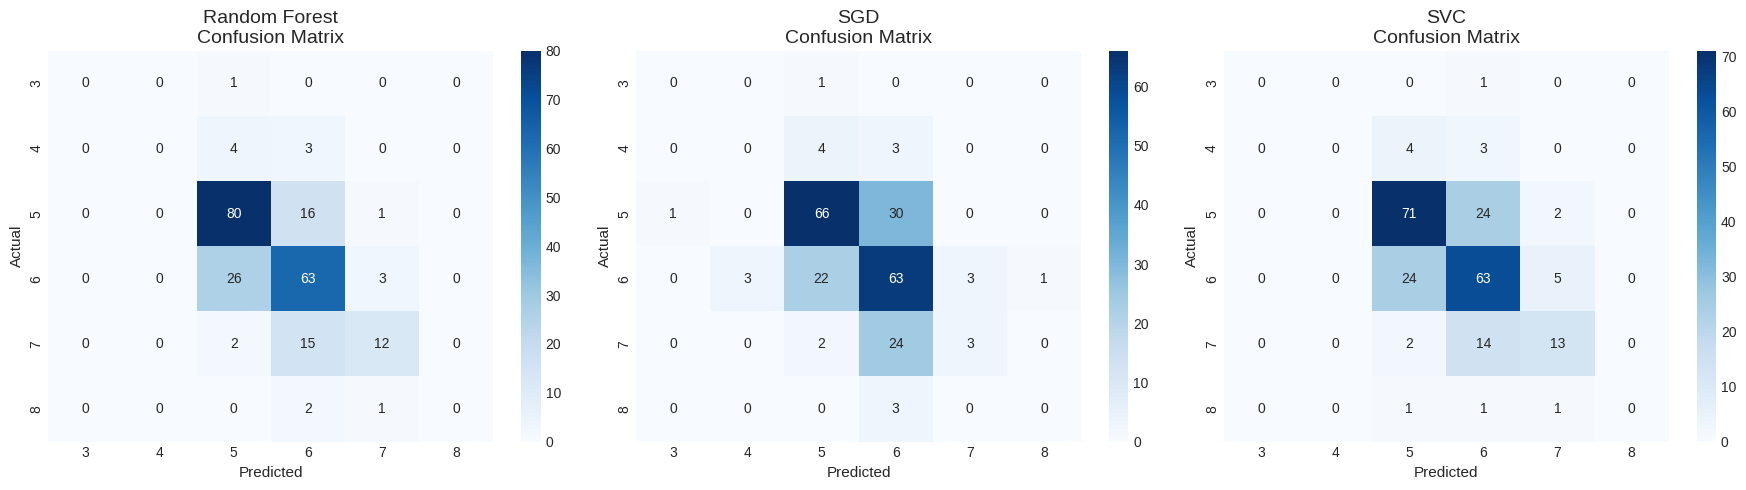


CROSS-VALIDATION RESULTS (5-Fold)

Random Forest:
  Mean accuracy: 0.6324 (+/- 0.0473)
  Individual scores: [0.6284153  0.61748634 0.63387978 0.60655738 0.67582418]

SGD:
  Mean accuracy: 0.5307 (+/- 0.1122)
  Individual scores: [0.5136612  0.45901639 0.52459016 0.52459016 0.63186813]

SVC:
  Mean accuracy: 0.6083 (+/- 0.0343)
  Individual scores: [0.61748634 0.59016393 0.6010929  0.59562842 0.63736264]

PREDICTION EXAMPLE
Sample features (row 0):
  fixed acidity: 5.2000
  volatile acidity: 0.3400
  citric acid: 0.0000
  residual sugar: 1.8000
  chlorides: 0.0500
  free sulfur dioxide: 27.0000
  total sulfur dioxide: 63.0000
  density: 0.9916
  pH: 3.6800
  sulphates: 0.7900
  alcohol: 14.0000

Actual quality: 6

Predictions from each model:
  Random Forest: 6
  SGD: 7
  SVC: 6


In [1]:

from google.colab import files
uploaded = files.upload()



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('WineQT.csv')

# Display basic information
print("=" * 80)
print("WINE QUALITY DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)
print(df.isnull().sum())

# Basic statistics
print("\n" + "=" * 80)
print("DATASET STATISTICS")
print("=" * 80)
print(df.describe())

# Check the distribution of quality scores
print("\n" + "=" * 80)
print("QUALITY SCORE DISTRIBUTION")
print("=" * 80)
print(df['quality'].value_counts().sort_index())

# Separate features and target
X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

print(f"\nFeature columns: {X.columns.tolist()}")
print(f"Target variable: quality (range: {y.min()} - {y.max()})")

# ============================================================================
# DATA VISUALIZATION
# ============================================================================
print("\n" + "=" * 80)
print("DATA VISUALIZATION")
print("=" * 80)

# Create subplots for feature distributions
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(X.columns):
    axes[idx].hist(X[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Remove empty subplots
for idx in range(len(X.columns), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Quality distribution
plt.figure(figsize=(10, 6))
quality_counts = df['quality'].value_counts().sort_index()
sns.barplot(x=quality_counts.index, y=quality_counts.values, palette='viridis')
plt.title('Distribution of Wine Quality Scores', fontsize=16)
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(quality_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('quality_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Feature vs Quality boxplots
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.ravel()

for idx, col in enumerate(X.columns):
    df.boxplot(column=col, by='quality', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Quality')
    axes[idx].set_xlabel('Quality')
    axes[idx].set_ylabel(col)

# Remove empty subplots
for idx in range(len(X.columns), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Feature Distributions by Quality Score', fontsize=16)
plt.tight_layout()
plt.savefig('feature_vs_quality.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# DATA PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized using StandardScaler")

# ============================================================================
# MODEL BUILDING AND EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("MODEL BUILDING AND EVALUATION")
print("=" * 80)

# Dictionary to store results
results = {}
models = {}

# 1. Random Forest Classifier
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_pred)
results['Random Forest'] = rf_accuracy
models['Random Forest'] = rf_model

print(f"Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Most Important Features:")
print(feature_importance.head(5))

# 2. Stochastic Gradient Descent Classifier
print("\n--- Stochastic Gradient Descent Classifier ---")
sgd_model = SGDClassifier(
    loss='modified_huber',
    penalty='elasticnet',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)
sgd_model.fit(X_train_scaled, y_train)
sgd_pred = sgd_model.predict(X_test_scaled)
sgd_accuracy = accuracy_score(y_test, sgd_pred)
results['SGD'] = sgd_accuracy
models['SGD'] = sgd_model

print(f"Accuracy: {sgd_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, sgd_pred))

# 3. Support Vector Classifier
print("\n--- Support Vector Classifier (SVC) ---")
# Using GridSearch to find best parameters for SVC
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svc_model = SVC(random_state=42)
grid_search = GridSearchCV(
    svc_model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_scaled, y_train)

best_svc = grid_search.best_estimator_
svc_pred = best_svc.predict(X_test_scaled)
svc_accuracy = accuracy_score(y_test, svc_pred)
results['SVC'] = svc_accuracy
models['SVC'] = best_svc

print(f"Best parameters: {grid_search.best_params_}")
print(f"Accuracy: {svc_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svc_pred))

# ============================================================================
# MODEL COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
}).sort_values('Accuracy', ascending=False)

print("\nModel Performance Summary:")
print(comparison_df.to_string(index=False))

# Visualization of model comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'],
               color=['#2ecc71', '#3498db', '#e74c3c'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Add accuracy values on bars
for bar, acc in zip(bars, comparison_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# CONFUSION MATRICES
# ============================================================================
print("\n" + "=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_list = [('Random Forest', rf_pred), ('SGD', sgd_pred), ('SVC', svc_pred)]

for idx, (model_name, predictions) in enumerate(models_list):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=14)
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# CROSS-VALIDATION
# ============================================================================
print("\n" + "=" * 80)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("=" * 80)

cv_results = {}
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[model_name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"\n{model_name}:")
    print(f"  Mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Individual scores: {cv_scores}")

# ============================================================================
# PREDICTION EXAMPLE
# ============================================================================
print("\n" + "=" * 80)
print("PREDICTION EXAMPLE")
print("=" * 80)

# Take a sample from test set
sample_idx = 0
sample_features = X_test.iloc[sample_idx]
sample_actual = y_test.iloc[sample_idx]

print(f"Sample features (row {sample_idx}):")
for col, val in sample_features.items():
    print(f"  {col}: {val:.4f}")

print(f"\nActual quality: {sample_actual}")

print("\nPredictions from each model:")
for model_name, model in models.items():
    sample_scaled = scaler.transform([sample_features.values])
    pred = model.predict(sample_scaled)[0]
    print(f"  {model_name}: {pred}")

